In [22]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import warnings

warnings.filterwarnings('ignore')

df=pd.read_csv("analitic_avito_dataset_50_pages.csv")

df['price']=pd.to_numeric(df['price'].astype(str).str.replace(r'[^\d.]', '', regex=True), errors='coerce')
df['space']=pd.to_numeric(df['space'].astype(str).str.replace(r'[^\d.]', '', regex=True), errors='coerce')
df['area_price']=pd.to_numeric(df['area_price'].astype(str).str.replace(r'[^\d.]', '', regex=True), errors='coerce')
df['time_to_metro']=pd.to_numeric(df['time_to_metro'].astype(str).str.replace(r'[^\d.]', '', regex=True), errors='coerce')

df=df.dropna(subset=['price', 'space', 'area_price', 'time_to_metro'])
print(df.shape)
print(df.dtypes)

(1917, 9)
type               str
space            int64
price            int64
area_price       int64
address            str
metro              str
time_to_metro    int64
date               str
source             str
dtype: object


In [23]:
mu0 = 15
t_stat, p_val = stats.ttest_1samp(df['time_to_metro'].dropna(), popmean=mu0)

print(f"t-статистика: {t_stat:.4f}")
print(f"p-value: {p_val:.4f}")
print(f"Среднее в выборке: {df['time_to_metro'].mean():.2f}")

if p_val < 0.05:
    print("Отвергаем H₀: среднее значимо отличается от 15 минут")
else:
    print("Нет оснований отвергать H₀")

t-статистика: 16.9198
p-value: 0.0000
Среднее в выборке: 18.60
Отвергаем H₀: среднее значимо отличается от 15 минут


In [24]:
m0 = 10_000_000
data = df['price'].dropna()

n_above = (data > m0).sum()
n_below = (data < m0).sum()
n_total = n_above + n_below

p_sign = 2 * stats.binom.cdf(min(n_above, n_below), n_total, 0.5)

print(f"Наблюдений выше m0: {n_above}")
print(f"Наблюдений ниже m0: {n_below}")
print(f"p-value (критерий знаков): {p_sign:.4f}")
print(f"Медиана в выборке: {data.median():,.0f}")

if p_sign < 0.05:
    print("Отвергаем H₀: медиана значимо отличается от 10 млн")
else:
    print("Нет оснований отвергать H₀")

Наблюдений выше m0: 1005
Наблюдений ниже m0: 901
p-value (критерий знаков): 0.0183
Медиана в выборке: 10,500,000
Отвергаем H₀: медиана значимо отличается от 10 млн


In [25]:
threshold = 15_000_000
p0 = 0.20

expensive = (df['price'] > threshold).sum()
n = df['price'].notna().sum()
observed_p = expensive / n

result = stats.binomtest(expensive, n, p0, alternative='two-sided')

print(f"Квартир дороже {threshold:,}: {expensive} из {n}")
print(f"Наблюдаемая доля: {observed_p:.3f} ({observed_p*100:.1f}%)")
print(f"p-value: {result.pvalue:.4f}")

if result.pvalue < 0.05:
    print("Отвергаем H₀: доля значимо отличается от 20%")
else:
    print("Нет оснований отвергать H₀")

Квартир дороже 15,000,000: 433 из 1917
Наблюдаемая доля: 0.226 (22.6%)
p-value: 0.0051
Отвергаем H₀: доля значимо отличается от 20%


In [26]:
group1 = df[df['type'] == '1-к. кв.']['price'].dropna()
group2 = df[df['type'] == '2-к. кв.']['price'].dropna()

print(f"Группа 1 (1к): n={len(group1)}, медиана={group1.median():,.0f}")
print(f"Группа 2 (2к): n={len(group2)}, медиана={group2.median():,.0f}")

t_stat, p_ttest = stats.ttest_ind(group1, group2, equal_var=False)
print(f"\nt-тест Уэлча: t={t_stat:.3f}, p={p_ttest:.4f}")

u_stat, p_mw = stats.mannwhitneyu(group1, group2, alternative='two-sided')
print(f"Манн-Уитни: U={u_stat:.1f}, p={p_mw:.4f}")

n1, n2 = len(group1), len(group2)
cohens_d = (group1.mean() - group2.mean()) / np.sqrt(((n1-1)*group1.std()**2 + (n2-1)*group2.std()**2) / (n1+n2-2))
print(f"\nРазмер эффекта Cohen's d: {cohens_d:.3f}")

r_effect = u_stat / (n1 * n2)
print(f"Размер эффекта r (для Манн-Уитни): {r_effect:.3f}")

Группа 1 (1к): n=0, медиана=nan
Группа 2 (2к): n=0, медиана=nan

t-тест Уэлча: t=nan, p=nan
Манн-Уитни: U=nan, p=nan

Размер эффекта Cohen's d: nan
Размер эффекта r (для Манн-Уитни): nan


In [27]:
df['metro_group'] = pd.cut(df['time_to_metro'], bins=[0, 10, 20, 100],
                            labels=['близко (≤10)', 'средне (11-20)', 'далеко (>20)'])

top_types = df['type'].value_counts().head(5).index
df_filtered = df[df['type'].isin(top_types)]

ct = pd.crosstab(df_filtered['type'], df_filtered['metro_group'])
print("Таблица сопряженности:")
print(ct)

chi2, p_chi2, dof, expected = stats.chi2_contingency(ct)
print(f"\nχ²-статистика: {chi2:.3f}")
print(f"Степени свободы: {dof}")
print(f"p-value: {p_chi2:.4f}")

n = ct.sum().sum()
v_cramer = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
print(f"V-Крамера (размер эффекта): {v_cramer:.3f}")

if p_chi2 < 0.05:
    print("Отвергаем H₀: тип квартиры и удалённость от метро связаны")
else:
    print("Нет оснований отвергать H₀")

Таблица сопряженности:
metro_group         близко (≤10)  средне (11-20)  далеко (>20)
type                                                          
1-к. квартира                116             206           248
2-к. квартира                165             197           162
3-к. квартира                116             118            81
Апартаменты-студия            56              31             9
Квартира-студия              123              58            97

χ²-статистика: 118.290
Степени свободы: 8
p-value: 0.0000
V-Крамера (размер эффекта): 0.182
Отвергаем H₀: тип квартиры и удалённость от метро связаны


Пирсон: r=0.794, p=0.0000
Спирмен: r=0.841, p=0.0000


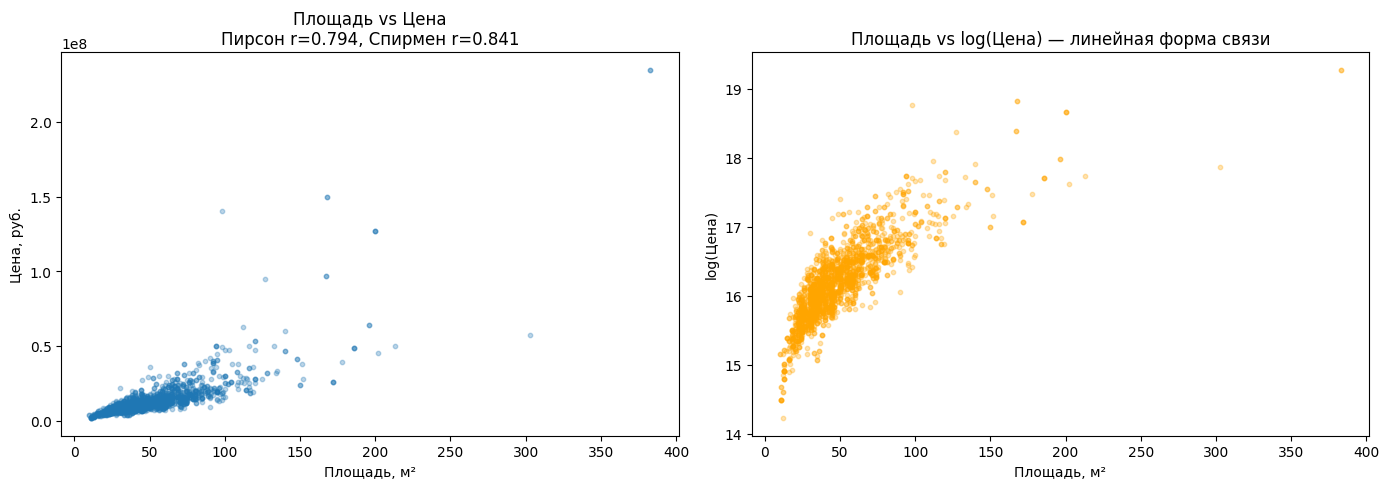

In [28]:
r_pearson, p_pearson = stats.pearsonr(df['space'].dropna(), df['price'].dropna())
r_spearman, p_spearman = stats.spearmanr(df['space'].dropna(), df['price'].dropna())

print(f"Пирсон: r={r_pearson:.3f}, p={p_pearson:.4f}")
print(f"Спирмен: r={r_spearman:.3f}, p={p_spearman:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df['space'], df['price'], alpha=0.3, s=10)
axes[0].set_xlabel('Площадь, м²')
axes[0].set_ylabel('Цена, руб.')
axes[0].set_title(f'Площадь vs Цена\nПирсон r={r_pearson:.3f}, Спирмен r={r_spearman:.3f}')

axes[1].scatter(df['space'], np.log(df['price']), alpha=0.3, s=10, color='orange')
axes[1].set_xlabel('Площадь, м²')
axes[1].set_ylabel('log(Цена)')
axes[1].set_title('Площадь vs log(Цена) — линейная форма связи')

plt.tight_layout()
plt.savefig('correlation_space_price.png', dpi=150)
plt.show()

In [29]:
top_types = df['type'].value_counts().head(4).index.tolist()
groups = [df[df['type'] == t]['area_price'].dropna().values for t in top_types]

f_stat, p_anova = stats.f_oneway(*groups)
print(f"ANOVA: F={f_stat:.3f}, p={p_anova:.4f}")

h_stat, p_kruskal = stats.kruskal(*groups)
print(f"Краскал-Уоллис: H={h_stat:.3f}, p={p_kruskal:.4f}")

if p_anova < 0.05:
    print("\nANOVA значима — делаем post-hoc тест Тьюки:")
    df_anova = df[df['type'].isin(top_types)][['type', 'area_price']].dropna()
    tukey = pairwise_tukeyhsd(df_anova['area_price'], df_anova['type'], alpha=0.05)
    print(tukey)

ss_between = sum(len(g) * (np.mean(g) - np.mean(np.concatenate(groups)))**2 for g in groups)
ss_total = sum((x - np.mean(np.concatenate(groups)))**2 for g in groups for x in g)
eta_sq = ss_between / ss_total
print(f"\nРазмер эффекта η² (эта-квадрат): {eta_sq:.3f}")
print("Интерпретация: 0.01 — малый, 0.06 — средний, 0.14 — большой")

ANOVA: F=8.115, p=0.0000
Краскал-Уоллис: H=113.713, p=0.0000

ANOVA значима — делаем post-hoc тест Тьюки:
             Multiple Comparison of Means - Tukey HSD, FWER=0.05              
    group1         group2       meandiff  p-adj     lower      upper    reject
------------------------------------------------------------------------------
1-к. квартира   2-к. квартира  -9580.6566 0.2185 -22389.3741  3228.0608  False
1-к. квартира   3-к. квартира -16481.4475 0.0228 -31340.0849   -1622.81   True
1-к. квартира Квартира-студия  14041.9586 0.0912  -1440.4368  29524.354  False
2-к. квартира   3-к. квартира  -6900.7908 0.6421 -21989.7789  8188.1972  False
2-к. квартира Квартира-студия  23622.6152 0.0007   7919.0162 39326.2143   True
3-к. квартира Квартира-студия   30523.406    0.0  13107.3535 47939.4586   True
------------------------------------------------------------------------------

Размер эффекта η² (эта-квадрат): 0.014
Интерпретация: 0.01 — малый, 0.06 — средний, 0.14 — большой


In [ ]:
results_summary = pd.DataFrame({
    'Вопрос': [
        'Среднее time_to_metro = 15 мин?',
        'Медиана price = 10 млн?',
        'Доля дорогих квартир = 20%?',
        'Цена: 1к vs 2к',
        'Тип квартиры и удалённость от метро',
        'Корреляция площади и цены',
        'Цена/м² по типам квартир (ANOVA)',
    ],
    'Переменные': [
        'time_to_metro', 'price', 'price', 
        'price × type', 'type × metro_group',
        'space, price', 'area_price × type'
    ],
    'Критерий': [
        't-тест одновыборочный', 'Критерий знаков', 'Биномиальный тест',
        'Манн-Уитни', 'χ²', 'Спирмен', 'ANOVA + Тьюки'
    ],
    'p-value': [
        p_val, p_sign, result.pvalue,
        p_mw, p_chi2, p_spearman, p_anova
    ],
    'Решение': [
        'Отвергаем H₀' if p_val < 0.05 else 'Не отвергаем H₀',
        'Отвергаем H₀' if p_sign < 0.05 else 'Не отвергаем H₀',
        'Отвергаем H₀' if result.pvalue < 0.05 else 'Не отвергаем H₀',
        'Отвергаем H₀' if p_mw < 0.05 else 'Не отвергаем H₀',
        'Отвергаем H₀' if p_chi2 < 0.05 else 'Не отвергаем H₀',
        'Отвергаем H₀' if p_spearman < 0.05 else 'Не отвергаем H₀',
        'Отвергаем H₀' if p_anova < 0.05 else 'Не отвергаем H₀',
    ]
})

print(results_summary.to_string(index=False))

                             Вопрос         Переменные              Критерий      p-value         Решение
    Среднее time_to_metro = 15 мин?      time_to_metro t-тест одновыборочный 5.824658e-60    Отвергаем H₀
            Медиана price = 10 млн?              price       Критерий знаков 1.828818e-02    Отвергаем H₀
        Доля дорогих квартир = 20%?              price     Биномиальный тест 5.131736e-03    Отвергаем H₀
                     Цена: 1к vs 2к       price × type            Манн-Уитни          NaN Не отвергаем H₀
Тип квартиры и удалённость от метро type × metro_group                    χ² 7.471512e-22    Отвергаем H₀
          Корреляция площади и цены       space, price               Спирмен 0.000000e+00    Отвергаем H₀
   Цена/м² по типам квартир (ANOVA)  area_price × type         ANOVA + Тьюки 2.293920e-05    Отвергаем H₀
